In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LogNorm
from matplotlib.ticker import AutoMinorLocator
from scipy.optimize import curve_fit
import os, sys

CAFPYANA_WD  = "/home/castalyf/cafpyana"
ANALYSIS_DIR = "."
PLOT_DIR     = "./shower_plots"
DF_OUT_DIR   = "./nuecc_dfs"
TITLE        = r"SBND $\nu_e$ CC Inclusive"

os.makedirs(PLOT_DIR, exist_ok=True)
for p in [CAFPYANA_WD, CAFPYANA_WD + "/pyanalib", ANALYSIS_DIR]:
    if p not in sys.path:
        sys.path.insert(0, p)

import nue_helpers as nh
%load_ext autoreload
%autoreload 2
print("imports OK")

imports OK


In [2]:
SEL_TOPO_FILE = os.path.join(DF_OUT_DIR, "selected_nuecc_topo.df")
sel_topo = pd.read_hdf(SEL_TOPO_FILE)
print(f"sel_topo shape : {sel_topo.shape}")
print(f"columns        : {list(sel_topo.columns)}")

# ── Signal + final-state topology mask ───────────────────────────────────────
sig_se = sel_topo["is_sig"] & sel_topo["sel_single_electron"]
print(f"\nSignal events after single-electron topo cut: {sig_se.sum():,}")

# ── KE, cos θ, momentum  (use actual column names from sel_topo) ─────────────
true_ke = sel_topo.loc[sig_se, "true_ke"]
reco_ke = sel_topo.loc[sig_se, "reco_ke"]
true_ct = sel_topo.loc[sig_se, "true_costheta"]   # fixed
reco_ct = sel_topo.loc[sig_se, "reco_costheta"]   # fixed
true_p  = sel_topo.loc[sig_se, "true_p"]          # already saved
reco_p  = sel_topo.loc[sig_se, "reco_p"]          # already saved

print(f"true_ke  : {true_ke.notna().sum():,} valid")
print(f"reco_ke  : {reco_ke.notna().sum():,} valid")
print(f"true_ct  : {true_ct.notna().sum():,} valid")

sel_topo shape : (603715, 13)
columns        : ['truth_cat', 'is_sig', 'reco_ke', 'reco_costheta', 'reco_p', 'true_ke', 'true_costheta', 'true_p', 'sel_precut', 'sel_valid_flashmatch', 'sel_fiducial', 'sel_single_electron', 'pot_scale']

Signal events after single-electron topo cut: 2,241
true_ke  : 2,241 valid
reco_ke  : 2,241 valid
true_ct  : 2,241 valid


/home/castalyf/cafpyana/analysis_village/nueCC/./nue_helpers.py:574: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


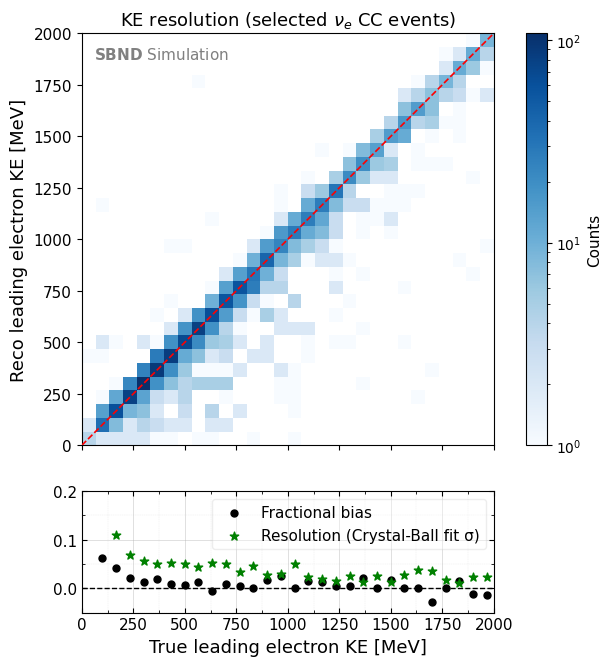

/home/castalyf/cafpyana/analysis_village/nueCC/./nue_helpers.py:1309: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/home/castalyf/cafpyana/analysis_village/nueCC/./nue_helpers.py:574: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


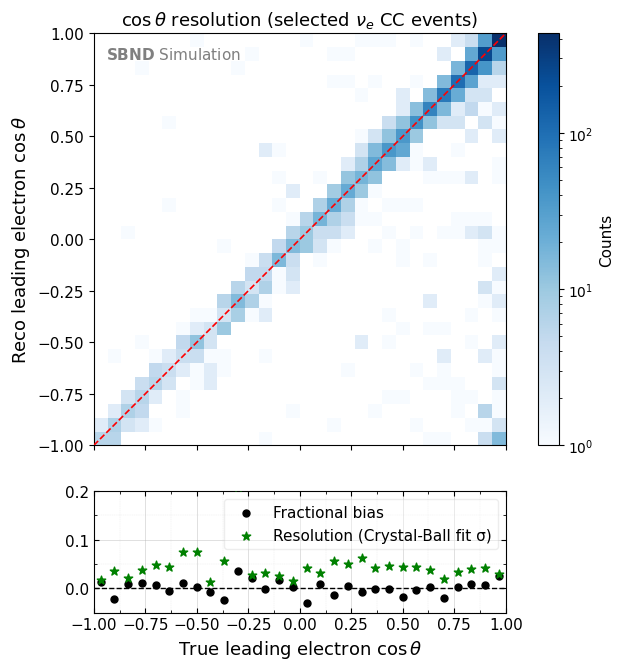

/home/castalyf/cafpyana/analysis_village/nueCC/./nue_helpers.py:1309: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/home/castalyf/cafpyana/analysis_village/nueCC/./nue_helpers.py:574: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


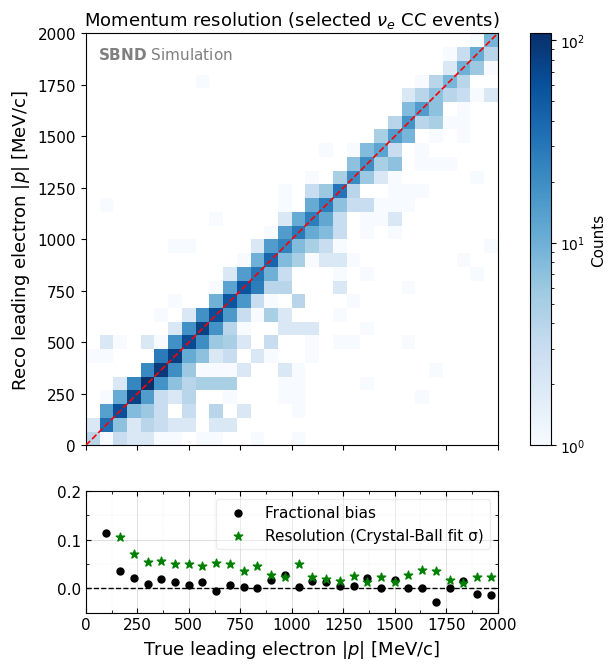

/home/castalyf/cafpyana/analysis_village/nueCC/./nue_helpers.py:1309: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


In [3]:
ke_bins_2d = np.linspace(0,   2000, 31)
ct_bins_2d = np.linspace(-1,    1, 31)
p_bins_2d  = np.linspace(0,  2000, 31)

# KE
fig_ke, _ = nh.plot_leading_e_resolution(
    true_series = true_ke, reco_series = reco_ke,
    bins        = ke_bins_2d, stage_idx = None,
    xlabel      = 'True leading electron KE [MeV]',
    ylabel      = 'Reco leading electron KE [MeV]',
    normalize   = True,  log_color = True,
    title       = fr"KE resolution (selected $\nu_e$ CC events)",
)
plt.show()
nh.save_plot("resolution_ke_topo", fig=fig_ke, folder_name=PLOT_DIR)

# cos θ
fig_ct, _ = nh.plot_leading_e_resolution(
    true_series = true_ct, reco_series = reco_ct,
    bins        = ct_bins_2d, stage_idx = None,
    xlabel      = r'True leading electron $\cos\theta$',
    ylabel      = r'Reco leading electron $\cos\theta$',
    normalize   = False, log_color = True,
    title       = fr"$\cos\theta$ resolution (selected $\nu_e$ CC events)",
)
plt.show()
nh.save_plot("resolution_costheta_topo", fig=fig_ct, folder_name=PLOT_DIR)

# momentum
fig_p, _ = nh.plot_leading_e_resolution(
    true_series = true_p, reco_series = reco_p,
    bins        = p_bins_2d, stage_idx = None,
    xlabel      = r'True leading electron $|p|$ [MeV/c]',
    ylabel      = r'Reco leading electron $|p|$ [MeV/c]',
    normalize   = True,  log_color = True,
    title       = fr"Momentum resolution (selected $\nu_e$ CC events)",
)
plt.show()
nh.save_plot("resolution_p_topo", fig=fig_p, folder_name=PLOT_DIR)

In [4]:
from scipy.optimize import curve_fit
from scipy.stats import norm as sp_norm

# ═══════════════════════════════════════════════════════════════════════════════
# Fit functions  — both take the SAME bins used for display
# ═══════════════════════════════════════════════════════════════════════════════
def _cb(t, A, alpha, n, mu, sigma):
    t   = np.asarray(t, dtype=float)
    out = np.empty_like(t)
    z   = (t - mu) / sigma
    g   = z > -alpha
    out[g]  = np.exp(-0.5 * z[g]**2)
    Ap = (n / alpha)**n * np.exp(-0.5 * alpha**2)
    Bp = n / alpha - alpha
    out[~g] = Ap * (Bp - z[~g])**(-n)
    return A * out


def _gauss(x, A, mu, sigma):
    return A * np.exp(-0.5 * ((x - mu) / sigma)**2)


def _fit_to_hist(stat, display_bins, fit_type='cb'):
    """
    Fit to the SAME histogram that will be displayed.
    Returns (popt, fit_ok, fit_fn, param_names)
    """
    counts, edges = np.histogram(stat, bins=display_bins)
    centers = 0.5 * (edges[:-1] + edges[1:])
    m  = float(np.nanmean(stat))
    s  = max(float(np.nanstd(stat)), 1e-9)
    A0 = max(float(counts.max()), 1.0)

    if fit_type == 'gauss':
        p0 = [A0,       m,        s      ]
        lo = [0,        m - 3*s,  1e-9   ]
        hi = [20*A0+1,  m + 3*s,  5*s    ]
        fn = _gauss
        names = ['A', 'mu', 'sigma']
    else:  # 'cb'
        p0 = [A0,       1.5,  2.0,   m,        s      ]
        lo = [0,        0.1,  1.01,  m - 3*s,  1e-9   ]
        hi = [20*A0+1,  5.,   50.,   m + 3*s,  5*s    ]
        fn = _cb
        names = ['A', 'alpha', 'n', 'mu', 'sigma']

    try:
        popt, _ = curve_fit(fn, centers, counts,
                            p0=p0, bounds=(lo, hi), maxfev=10000)
        return popt, True, fn, names
    except Exception:
        return p0, False, fn, names


In [5]:
# ═══════════════════════════════════════════════════════════════════════════════
# Per-bin panel plot  —  fit_type='cb' or 'gauss'
# ═══════════════════════════════════════════════════════════════════════════════
def plot_per_bin_panels(true_series, reco_series,
                        bins, bin_labels,
                        normalize    = True,
                        suptitle     = '',
                        bin_var_label= '',
                        unit         = '',
                        res_range    = (-1.0, 1.0),
                        n_cols       = 4,
                        n_fit_bins   = 60,
                        fit_type     = 'cb'):       # <── 'cb' or 'gauss'

    bins_arr = np.asarray(bins, dtype=float)
    n_bins   = len(bins_arr) - 1
    n_rows   = int(np.ceil(n_bins / n_cols))

    fig_w  = 5.0 * n_cols
    fig_h  = 4.0 * n_rows
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_w, fig_h))
    axes = np.array(axes).flatten()

    valid = true_series.notna() & reco_series.notna()
    xa    = true_series[valid].astype(float)
    ya    = reco_series[valid].astype(float)

    res_label  = (r'$(reco - true)\,/\,true$' if normalize else r'$reco - true$')
    fit_color  = 'salmon'   if fit_type == 'cb' else 'limegreen'
    fit_label  = 'Crystal Ball fit' if fit_type == 'cb' else 'Gaussian fit'

    # shared display bins — fit uses THESE exact bins
    display_bins = np.linspace(res_range[0], res_range[1], n_fit_bins + 1)

    for i in range(n_bins):
        ax     = axes[i]
        lo, hi = bins_arr[i], bins_arr[i + 1]
        label  = bin_labels[i] if bin_labels else (
            f'{lo:.2g}–{hi:.2g}' if hi != np.inf else f'>{lo:.2g}')

        in_bin = (xa > lo) & (xa <= hi)
        xb, yb = xa[in_bin], ya[in_bin]
        if normalize:
            keep   = np.abs(xb) > 1e-6
            xb, yb = xb[keep], yb[keep]
            stat   = ((yb - xb) / xb).dropna()
        else:
            stat = (yb - xb).dropna()

        n_entries = len(stat)
        raw_mean  = float(np.nanmean(stat)) if n_entries > 0 else np.nan
        raw_std   = float(np.nanstd(stat))  if n_entries > 0 else np.nan

        # ── fit (same bins as display) ────────────────────────────────────
        if n_entries >= 15:
            popt, fit_ok, fit_fn, pnames = _fit_to_hist(
                stat.values, display_bins, fit_type=fit_type)
            mu_fit    = popt[pnames.index('mu')]
            sigma_fit = popt[pnames.index('sigma')]
        else:
            fit_ok = False
            mu_fit = sigma_fit = np.nan

        # ── histogram ─────────────────────────────────────────────────────
        ax.hist(stat, bins=display_bins,
                color='steelblue', edgecolor='white', linewidth=0.3,
                label=f'{n_entries:,} Entries', zorder=2)

        # ── fit overlay (dense x so curve is smooth) ──────────────────────
        if fit_ok:
            t_fine = np.linspace(res_range[0], res_range[1], 600)
            ax.plot(t_fine, fit_fn(t_fine, *popt),
                    color=fit_color, lw=2.0, label=fit_label, zorder=3)

        # ── panel title ───────────────────────────────────────────────────
        unit_str = f' {unit}' if unit else ''
        ax.set_title(fr'{bin_var_label} {label}{unit_str}',
                     fontsize=9.5, pad=3)

        # ── annotation ────────────────────────────────────────────────────
        if fit_ok:
            txt = (f'Fit:\n'
                   f'  σ = {sigma_fit:.3f}\n'
                   f'  μ = {mu_fit:+.3f}\n\n'
                   f'Raw:\n'
                   f'  std  = {raw_std:.3f}\n'
                   f'  mean = {raw_mean:+.3f}')
        else:
            txt = (f'Raw:\n'
                   f'  std  = {raw_std:.3f}\n'
                   f'  mean = {raw_mean:+.3f}\n'
                   f'  (fit failed)')

        ax.text(0.03, 0.97, txt,
                transform=ax.transAxes, va='top', ha='left',
                fontsize=8, family='monospace')

        ax.legend(fontsize=7.5, loc='upper right')
        ax.set_xlabel(res_label, fontsize=8.5)
        ax.set_ylabel('Entries',  fontsize=8.5)
        ax.set_xlim(res_range)
        ax.axvline(0, ls='--', color='black', lw=0.8, alpha=0.5)
        ax.tick_params(labelsize=7.5)

    for j in range(n_bins, len(axes)):
        axes[j].set_visible(False)

    if suptitle:
        fig.suptitle(suptitle, fontsize=11, y=1.0)

    fig.tight_layout(rect=[0, 0, 1, 0.98 if suptitle else 1.0],
                     h_pad=3.0, w_pad=1.5)
    return fig, axes




In [6]:
# ═══════════════════════════════════════════════════════════════════════════════
# Binning
# ═══════════════════════════════════════════════════════════════════════════════
ke_bins_1d = np.array([0, 200, 400, 600, 800, 1000, 1500, 2000, np.inf])
ke_labels  = ["[0, 200]", "[200, 400]", "[400, 600]", "[600, 800]",
              "[800, 1000]", "[1000, 1500]", "[1500, 2000]", ">2000"]

ct_bins_1d = np.array([-1.0, -0.75, -0.5, -0.25, 0.0, 0.25, 0.5, 0.75, 1.0])
ct_labels  = [f"[{a:.2f}, {b:.2f}]"
              for a, b in zip(ct_bins_1d[:-1], ct_bins_1d[1:])]

p_bins_1d = np.array([0, 200, 400, 600, 800, 1000, 1500, 2000, np.inf])
p_labels  = ["[0, 200]", "[200, 400]", "[400, 600]", "[600, 800]",
              "[800, 1000]", "[1000, 1500]", "[1500, 2000]", ">2000"]


# ═══════════════════════════════════════════════════════════════════════════════
# Produce both CB and Gaussian versions for all three variables
# ═══════════════════════════════════════════════════════════════════════════════
_vars = [
    dict(true=true_ke, reco=reco_ke, bins=ke_bins_1d, labels=ke_labels,
         normalize=True,  var_label=r'$KE_{True}$ in', unit='MeV',
         res_range=(-1.0, 1.0), tag='ke',       name='KE'),
    dict(true=true_ct, reco=reco_ct, bins=ct_bins_1d, labels=ct_labels,
         normalize=False, var_label=r'$\cos\theta_{True}$ in', unit='',
         res_range=(-0.4, 0.4), tag='costheta', name=r'$\cos\theta$'),
    dict(true=true_p,  reco=reco_p,  bins=p_bins_1d,  labels=p_labels,
         normalize=True,  var_label=r'$p_{True}$ in', unit='MeV/c',
         res_range=(-1.0, 1.0), tag='p',        name=r'$|p|$'),
]

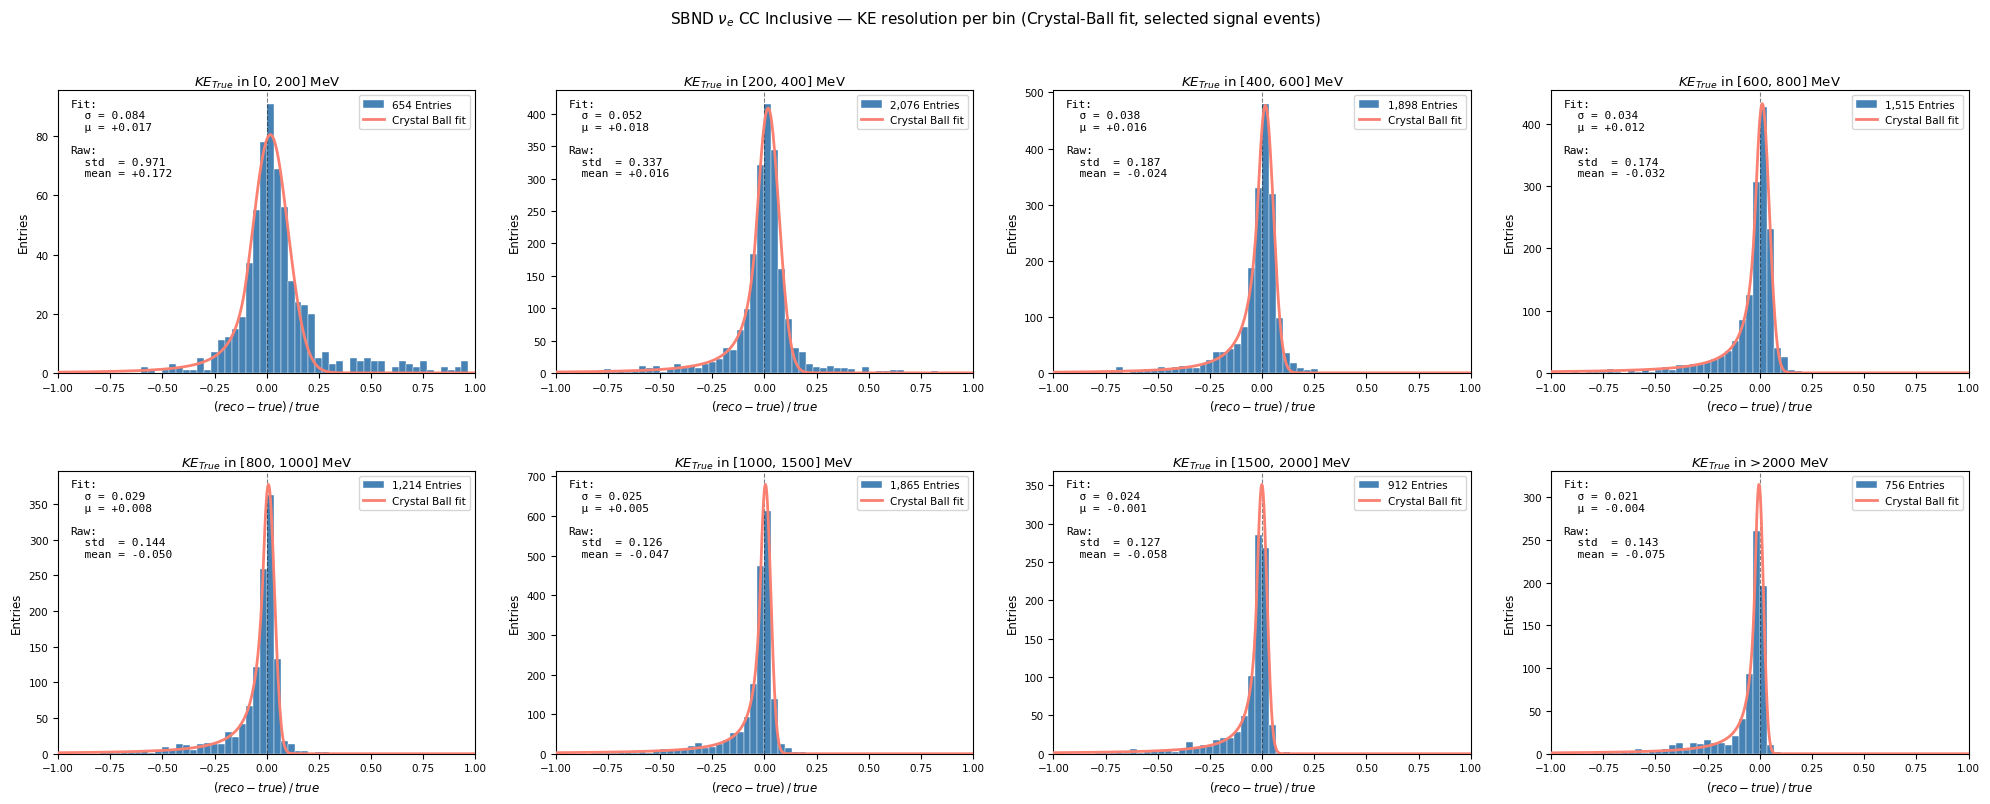

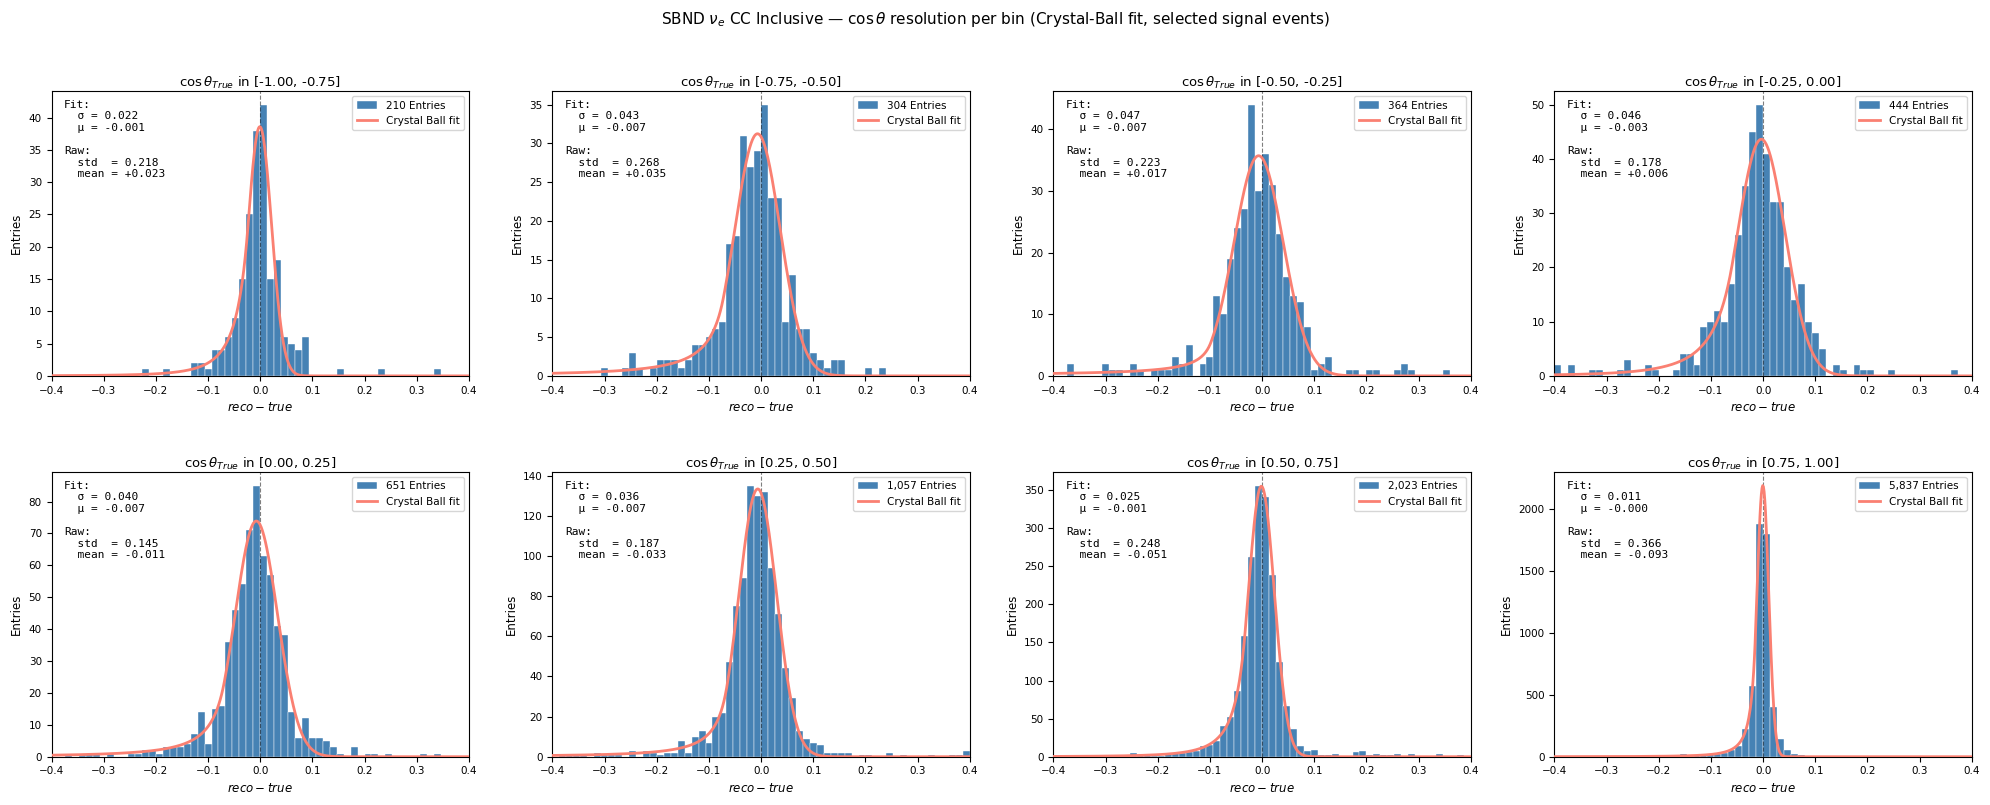

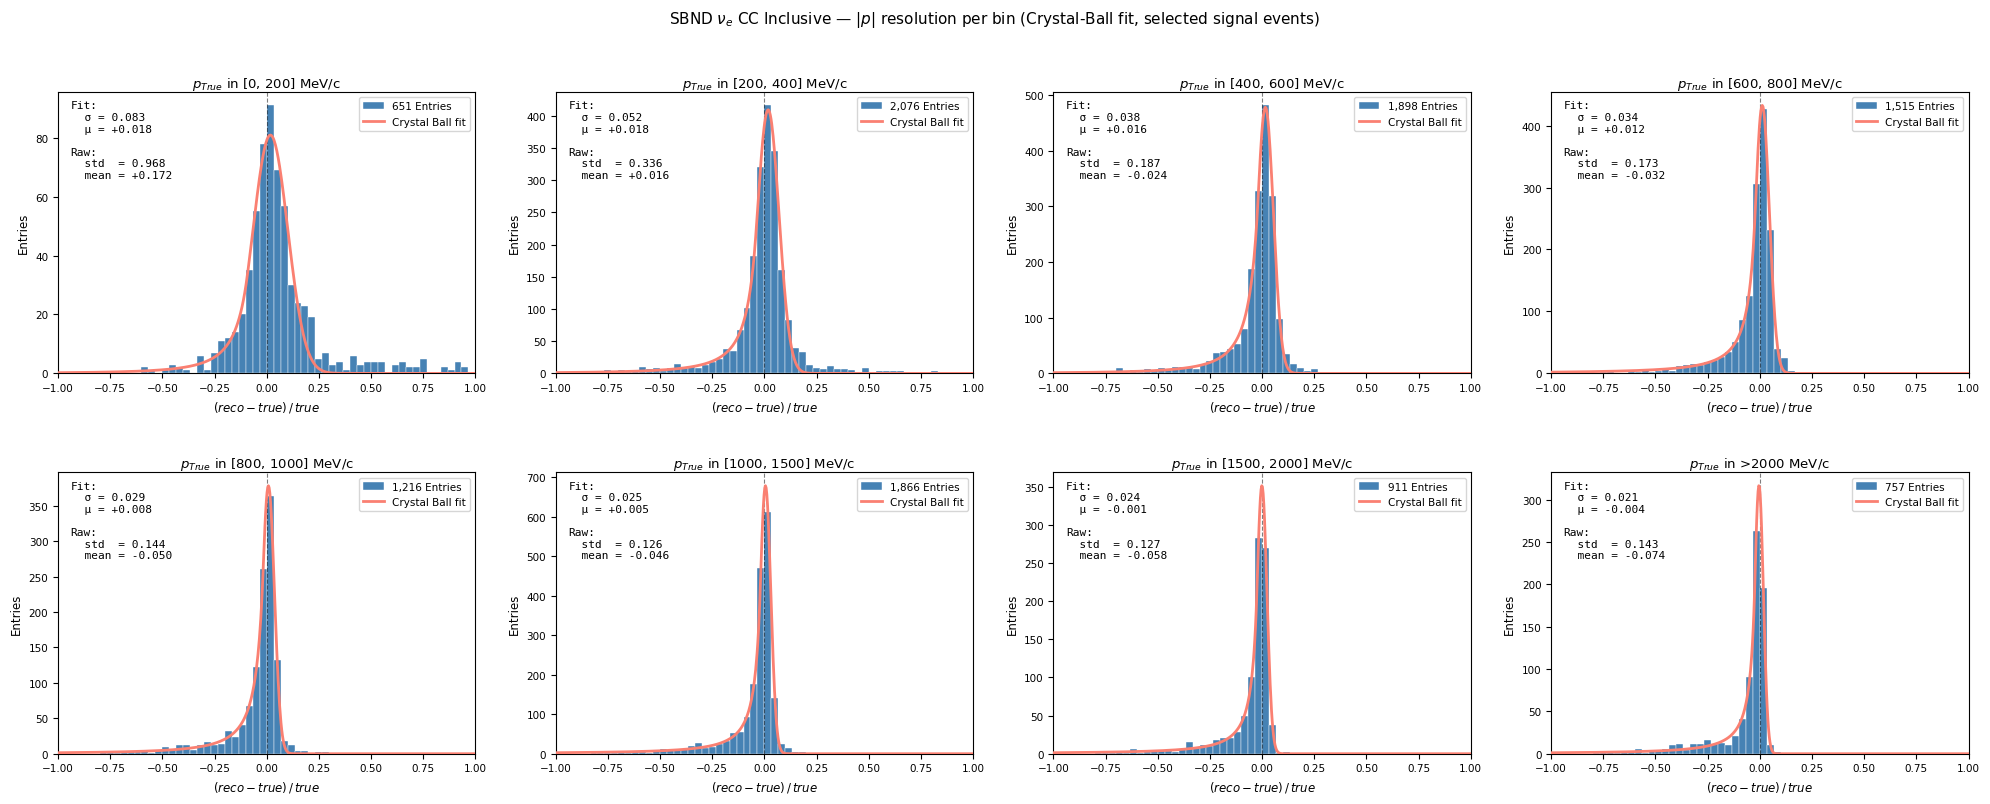

In [7]:
for v in _vars:
    fig, _ = plot_per_bin_panels(
        v['true'], v['reco'],
        bins          = v['bins'],
        bin_labels    = v['labels'],
        normalize     = v['normalize'],
        suptitle      = (fr"{TITLE} — {v['name']} resolution per bin"
                         fr" (Crystal-Ball fit, selected signal events)"),
        bin_var_label = v['var_label'],
        unit          = v['unit'],
        res_range     = v['res_range'],
        n_cols        = 4,
        fit_type      = 'cb',
    )
    plt.show()
    nh.save_plot(
        f"resolution_{v['tag']}_perbin_cb",
        fig=fig,
        folder_name=PLOT_DIR
    )

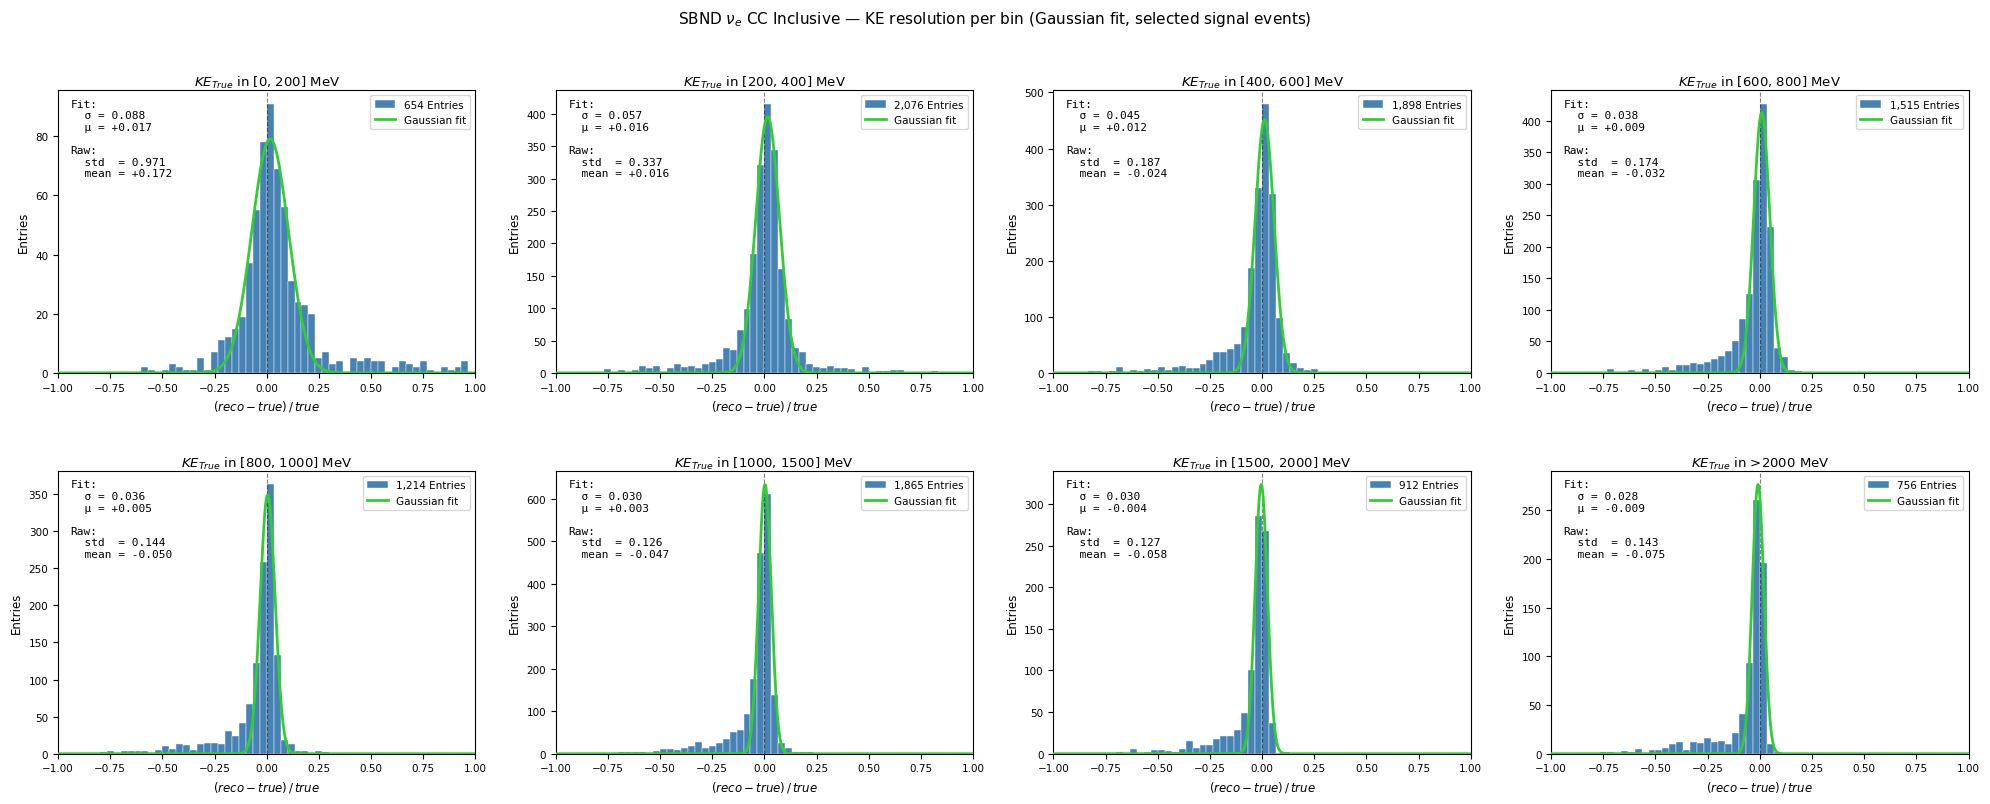

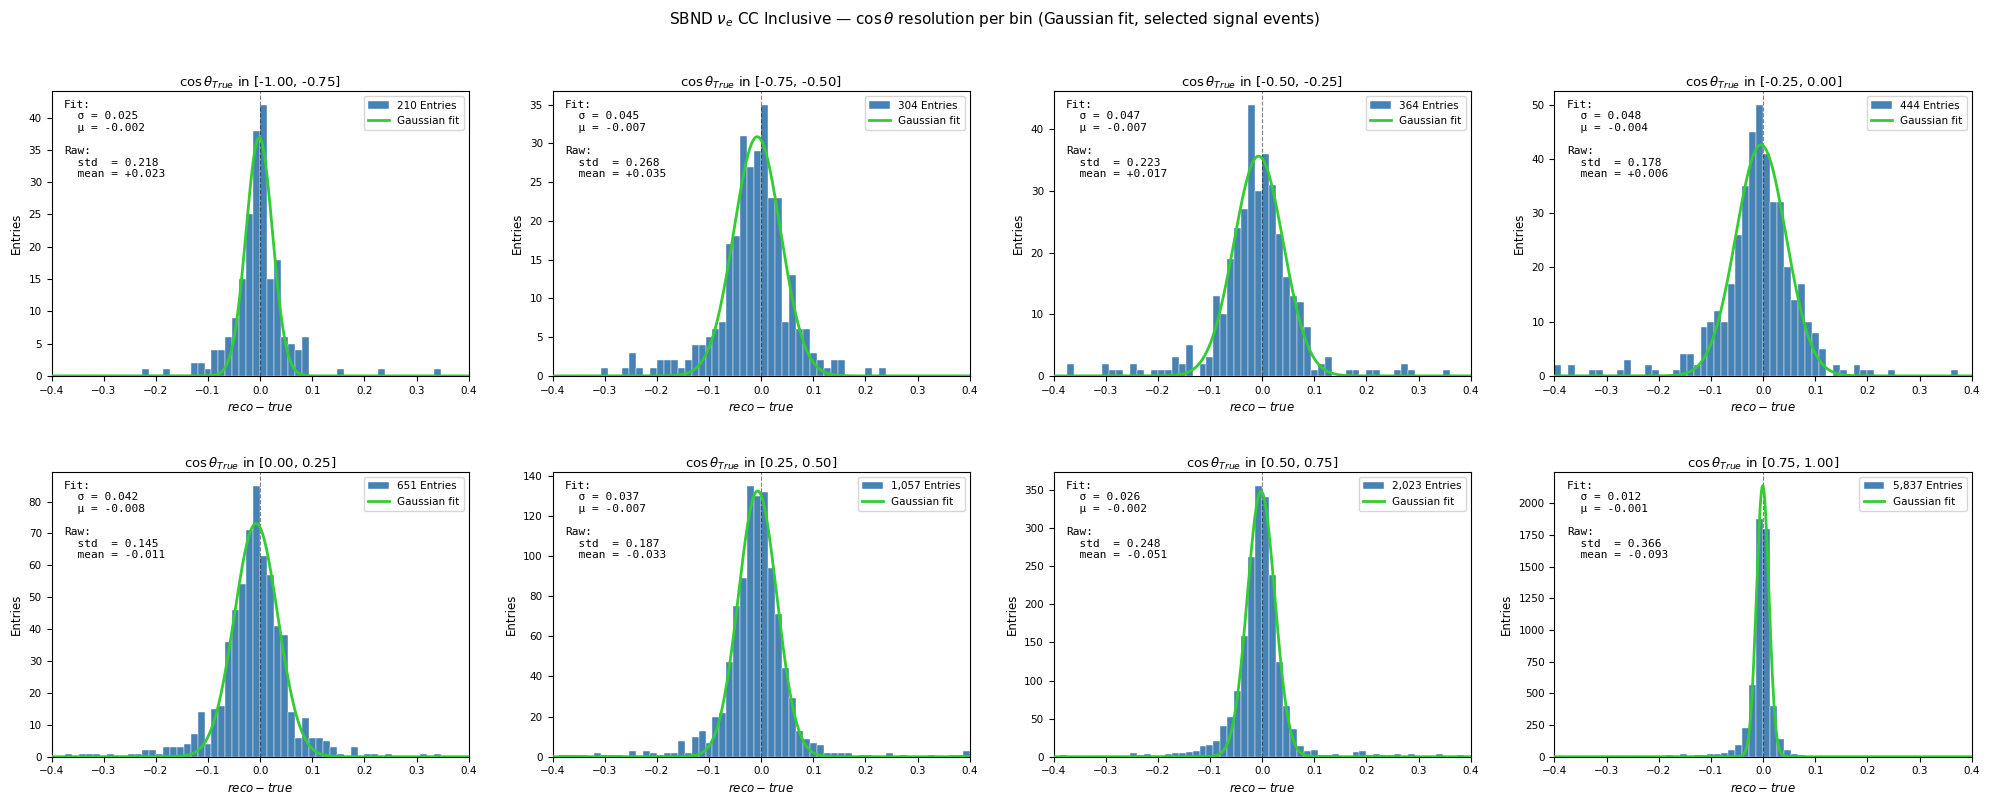

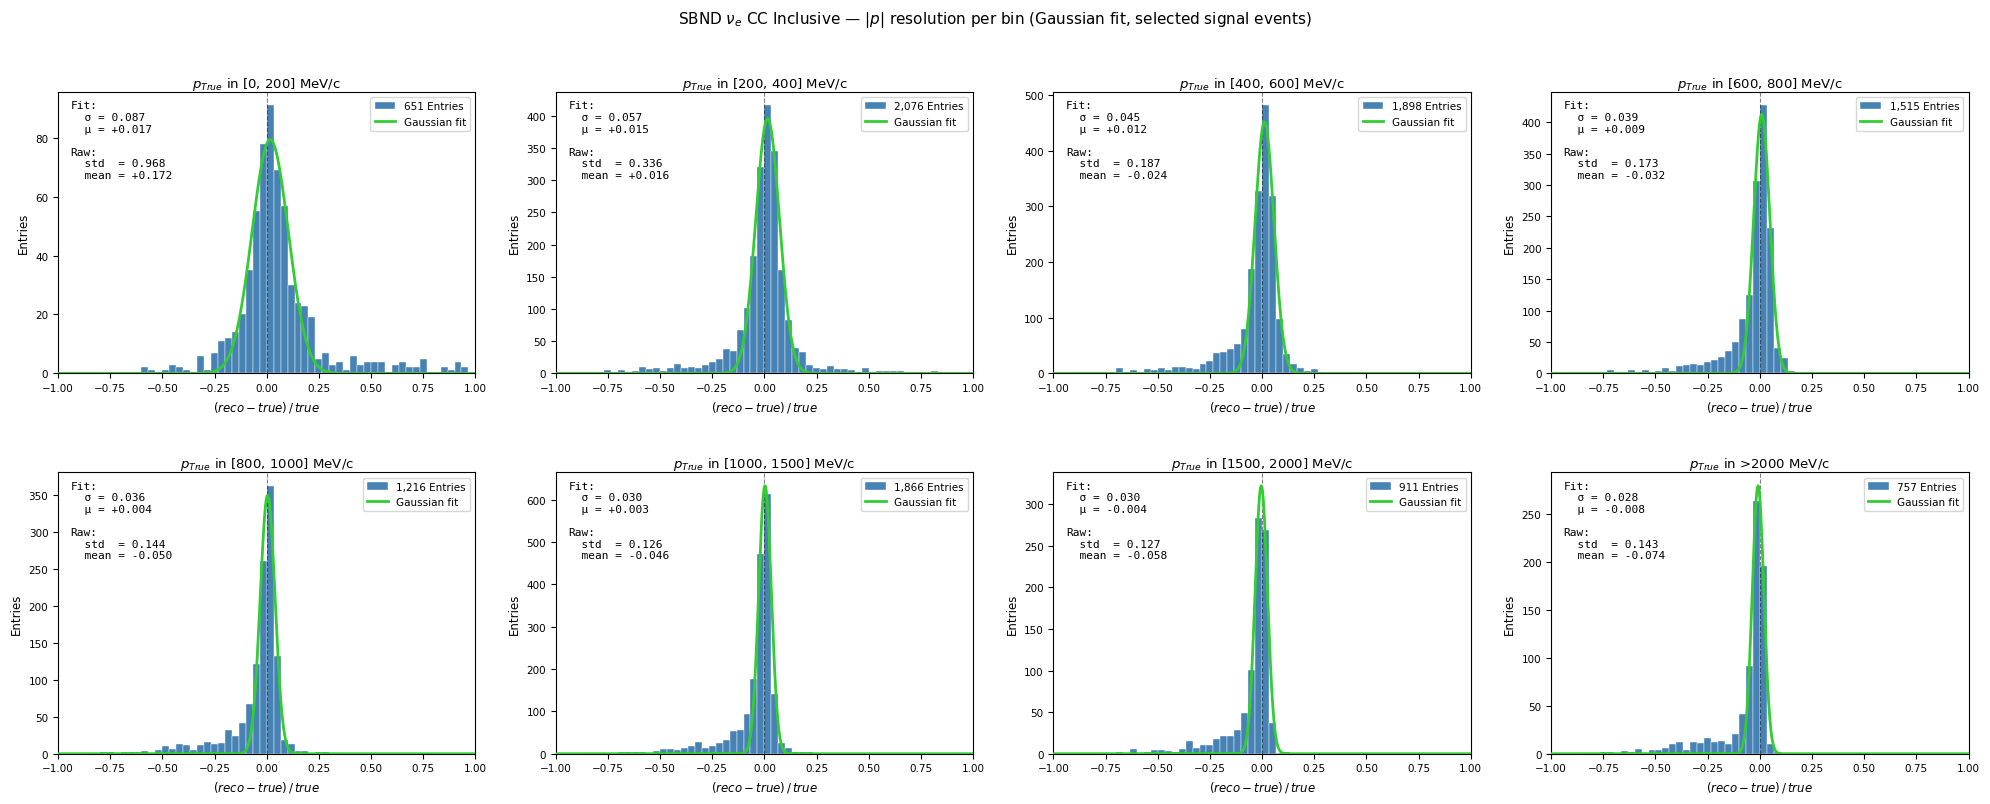

In [8]:
for v in _vars:
    fig, _ = plot_per_bin_panels(
        v['true'], v['reco'],
        bins          = v['bins'],
        bin_labels    = v['labels'],
        normalize     = v['normalize'],
        suptitle      = (fr"{TITLE} — {v['name']} resolution per bin"
                         fr" (Gaussian fit, selected signal events)"),
        bin_var_label = v['var_label'],
        unit          = v['unit'],
        res_range     = v['res_range'],
        n_cols        = 4,
        fit_type      = 'gauss',
    )
    plt.show()
    nh.save_plot(
        f"resolution_{v['tag']}_perbin_gauss",
        fig=fig,
        folder_name=PLOT_DIR
    )

In [9]:
SEL_TOPO_FILE = os.path.join(DF_OUT_DIR, "selected_nuecc_topo.df")
sel_topo = pd.read_hdf(SEL_TOPO_FILE)

sig_se = sel_topo["is_sig"] & sel_topo["sel_single_electron"]
sig_df = sel_topo[sig_se].copy()
sig_df["ke_ratio"]    = sig_df["reco_ke"] / sig_df["true_ke"]
sig_df["ke_frac_res"] = (sig_df["reco_ke"] - sig_df["true_ke"]) / sig_df["true_ke"]
sig_df["ct_sum"]      = sig_df["reco_costheta"] + sig_df["true_costheta"]

CT_TRUE_MIN = 0.80;  CT_RECO_MAX = -0.50
FRAC_LOW    = -0.50; TRUE_KE_MIN =  100.

mask_ct_flip  = (sig_df["true_costheta"] >= CT_TRUE_MIN) & \
                (sig_df["reco_costheta"]  <= CT_RECO_MAX)
mask_ke_under = (sig_df["ke_frac_res"] < FRAC_LOW) & \
                (sig_df["true_ke"]     > TRUE_KE_MIN)
mask_normal   = ~mask_ct_flip & ~mask_ke_under

print(f"Signal: {len(sig_df):,}  |  flip: {mask_ct_flip.sum()}  "
      f"|  KE-under: {mask_ke_under.sum()}  |  normal: {mask_normal.sum():,}")

Signal: 10,890  |  flip: 218  |  KE-under: 214  |  normal: 10,462


In [13]:
import glob, gc

DATA_DIR    = "/exp/sbnd/data/users/castalyf/nue_sel/production_files/gen1/"
PARTS_CACHE = os.path.join(DF_OUT_DIR, "parts_signal_cache.df")
NTUPLE_STEP = 10000   # confirmed from diagnostic

# ── build ntuple → filepath map ──────────────────────────────────────────────
all_files      = sorted(glob.glob(os.path.join(DATA_DIR, "mc*.df")))
ntuple_to_file = {i * NTUPLE_STEP: fp for i, fp in enumerate(all_files)}
print(f"Found {len(all_files)} ntuple files  (step={NTUPLE_STEP})")

# ── which ntuples do we need? ─────────────────────────────────────────────────
ntuples_needed = (
    set(sig_df[mask_ct_flip ].index.get_level_values("__ntuple")) |
    set(sig_df[mask_ke_under].index.get_level_values("__ntuple")) |
    set(sig_df[mask_normal  ].index.get_level_values("__ntuple"))
) & set(ntuple_to_file.keys())
print(f"Ntuples needed: {len(ntuples_needed)}")

COL_MAP = {
    "start_x"    : ("rec","dlp","particles","start_point","x"),
    "start_y"    : ("rec","dlp","particles","start_point","y"),
    "start_z"    : ("rec","dlp","particles","start_point","z"),
    "dir_x"      : ("rec","dlp","particles","start_dir","x"),
    "dir_y"      : ("rec","dlp","particles","start_dir","y"),
    "dir_z"      : ("rec","dlp","particles","start_dir","z"),
    "match_ov"   : ("rec","dlp","particles","match_overlaps",""),
    "is_contained": ("rec","dlp","particles","is_contained",""),
    "ke_reco"    : ("rec","dlp","particles","ke",""),
    "size_reco"  : ("rec","dlp","particles","size",""),
    "pid"        : ("rec","dlp","particles","pid",""),
    "is_primary" : ("rec","dlp","particles","is_primary",""),
    "true_dir_x" : ("rec","dlp_true","particles","start_dir","x"),
    "true_dir_y" : ("rec","dlp_true","particles","start_dir","y"),
    "true_dir_z" : ("rec","dlp_true","particles","start_dir","z"),
    "size_true"  : ("rec","dlp_true","particles","size",""),
}

def load_and_filter_ntuple(filepath, target_ntuple, col_map, wanted_entries):
    """
    Load one ntuple file, keep only rows for wanted (entry, dlp_idx) pairs.
    Loads all 33 cols but discards 99% of rows immediately → low peak memory.
    """
    with pd.HDFStore(filepath, mode="r") as store:
        keys = store.keys()
        has_split = "/split" in keys
    if has_split:
        with pd.HDFStore(filepath, mode="r") as store:
            n_sp = int(store["split"]["n_split"].iloc[0])
        frames = [pd.read_hdf(filepath, key=f"evt_{k}") for k in range(n_sp)]
    else:
        evt_keys = sorted([k for k in keys if k.lstrip("/").startswith("evt")])
        frames   = [pd.read_hdf(filepath, key=k) for k in evt_keys]
    raw = pd.concat(frames, axis=0)

    # select only our 33 columns
    avail = {k: v for k, v in col_map.items() if v in raw.columns}
    df    = raw[list(avail.values())].copy()
    df.columns = list(avail.keys())

    # fix ntuple index level
    idx = df.index.to_frame(index=False)
    idx.iloc[:, 0] = target_ntuple
    df.index = pd.MultiIndex.from_frame(idx, names=raw.index.names)

    # filter immediately to only wanted rows
    df_r = df.reset_index()
    df_r["_k"] = list(zip(df_r["__ntuple"].astype(np.int64),
                           df_r["entry"].astype(np.int64),
                           df_r["rec.dlp..index"].astype(np.int64)))
    result = df_r[df_r["_k"].isin(wanted_entries)].copy()
    del raw, df, df_r; gc.collect()
    return result


if os.path.exists(PARTS_CACHE):
    print("Loading cached particle data …")
    parts_r = pd.read_hdf(PARTS_CACHE)
else:
    # collect all wanted (ntuple, entry, dlp_idx) tuples across all populations
    all_wanted = (
        set(sig_df[mask_ct_flip ].index.tolist()) |
        set(sig_df[mask_ke_under].index.tolist()) |
        set(sig_df[mask_normal  ].index.tolist())
    )

    frames = []
    for i, nt in enumerate(tqdm(sorted(ntuples_needed), desc="Loading files")):
        fp = ntuple_to_file.get(nt)
        if fp is None:
            continue
        # only pass tuples belonging to this ntuple
        nt_wanted = {t for t in all_wanted if t[0] == nt}
        try:
            chunk = load_and_filter_ntuple(fp, nt, COL_MAP, nt_wanted)
            if len(chunk):
                frames.append(chunk)
        except Exception as e:
            print(f"  SKIP ntuple={nt}: {e}")

    parts_r = pd.concat(frames, ignore_index=True)
    parts_r.to_hdf(PARTS_CACHE, key="df", mode="w")
    print(f"Cached → {PARTS_CACHE}")

# ensure int64 join keys and tuple key column
for c in IDX_3:
    parts_r[c] = parts_r[c].astype(np.int64)
if "_k" not in parts_r.columns:
    parts_r["_k"] = list(zip(parts_r["__ntuple"],
                              parts_r["entry"],
                              parts_r["rec.dlp..index"]))

print(f"\nparts_r shape : {parts_r.shape}")
print(f"columns       : {[c for c in parts_r.columns if c != '_k']}")

Found 2 ntuple files  (step=10000)
Ntuples needed: 2


Loading files:   0%|          | 0/2 [00:00<?, ?it/s]

Cached → ./nuecc_dfs/parts_signal_cache.df

parts_r shape : (770, 21)
columns       : ['__ntuple', 'entry', 'rec.dlp..index', 'rec.dlp.particles..index', 'start_x', 'start_y', 'start_z', 'dir_x', 'dir_y', 'dir_z', 'match_ov', 'is_contained', 'ke_reco', 'size_reco', 'pid', 'is_primary', 'true_dir_x', 'true_dir_y', 'true_dir_z', 'size_true']


/tmp/ipykernel_13485/2680323395.py:102: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block4_values] [items->Index(['_k'], dtype='object')]

  parts_r.to_hdf(PARTS_CACHE, key="df", mode="w")


In [14]:
SENTINEL = -9e11
RECO_DIR = ["dir_x","dir_y","dir_z"]
TRUE_DIR = ["true_dir_x","true_dir_y","true_dir_z"]

def clean(series, lo=-1e10, hi=1e10):
    s = pd.to_numeric(series, errors="coerce").replace([-np.inf, np.inf], np.nan)
    return s.where((s > lo) & (s < hi))

def get_leading_electron(event_mask, parts_r, sig_df,
                          pid_shower=2, ke_col="ke_reco"):
    # ── 1. wanted set of (ntuple, entry, dlp_idx) 3-tuples ───────────────────
    wanted_tuples = set(sig_df[event_mask].index.tolist())  # exact Python tuples

    # ── 2. filter parts in one isin call ─────────────────────────────────────
    parts_filt = parts_r[parts_r["_k"].isin(wanted_tuples)].copy()

    if len(parts_filt) == 0:
        print("  WARNING: 0 rows matched"); return pd.DataFrame()

    # ── 3. primary showers only ───────────────────────────────────────────────
    prim = parts_filt[parts_filt["is_primary"] == 1] \
           if "is_primary" in parts_filt.columns else parts_filt
    if len(prim) == 0: prim = parts_filt
    shw = prim[prim["pid"] == pid_shower] \
          if "pid" in prim.columns else prim
    if len(shw) == 0: shw = prim

    # ── 4. leading electron = max ke_reco per interaction ────────────────────
    if ke_col in shw.columns:
        lead = shw.loc[shw.groupby(IDX_3)[ke_col].idxmax()].copy()
    else:
        lead = shw.groupby(IDX_3).first().reset_index()

    # ── 5. attach sig_df columns ──────────────────────────────────────────────
    sig_cols  = [c for c in ["true_ke","reco_ke","ke_ratio","ke_frac_res",
                              "true_costheta","reco_costheta","ct_sum"]
                 if c in sig_df.columns]
    sig_extra = sig_df[event_mask][sig_cols].reset_index()
    sig_extra.columns = IDX_3 + [f"sig_{c}" for c in sig_cols]
    for c in IDX_3:
        sig_extra[c] = sig_extra[c].astype(np.int64)

    return lead.merge(sig_extra, on=IDX_3, how="left").reset_index(drop=True)


def add_derived(df):
    df = df.copy()
    if all(c in df.columns for c in RECO_DIR + TRUE_DIR):
        r = df[RECO_DIR].values.astype(float)
        t = df[TRUE_DIR].values.astype(float)
        r[np.abs(r) > 1e10] = np.nan
        t[np.abs(t) > 1e10] = np.nan
        with np.errstate(invalid="ignore"):
            r_n = r / np.linalg.norm(r, axis=1, keepdims=True).clip(1e-9)
            t_n = t / np.linalg.norm(t, axis=1, keepdims=True).clip(1e-9)
        df["dir_dot"] = np.einsum("ij,ij->i", r_n, t_n)
    if "size_reco" in df.columns and "size_true" in df.columns:
        st = df["size_true"].replace(0, np.nan).where(lambda x: x > SENTINEL)
        df["size_ratio"] = df["size_reco"] / st
    return df


import time
from tqdm.auto import tqdm

results = {}
for label, mask in tqdm([("flip",   mask_ct_flip),
                          ("under",  mask_ke_under),
                          ("normal", mask_normal)],
                         desc="Extracting"):
    t0 = time.time()
    df = get_leading_electron(mask, parts_r, sig_df)
    results[label] = add_derived(df)
    print(f"  {label:6s}: {mask.sum():5d} events → {len(df):5d} matched "
          f"({time.time()-t0:.1f}s)")

parts_flip  = results["flip"]
parts_under = results["under"]
parts_norm  = results["normal"]

# ── sanity check ─────────────────────────────────────────────────────────────
if "dir_dot" in parts_flip.columns and len(parts_flip):
    dd = clean(parts_flip["dir_dot"]).dropna()
    print(f"\nFlip dir_dot: min={dd.min():.3f}  mean={dd.mean():.3f}  max={dd.max():.3f}")
    print(f"  < -0.5 : {(dd < -0.5).mean()*100:.0f}%  ← should be high for genuine flips")

Extracting:   0%|          | 0/3 [00:00<?, ?it/s]

  flip  :   218 events →     0 matched (0.0s)
  under :   214 events →     1 matched (0.0s)
  normal: 10462 events →    25 matched (0.0s)


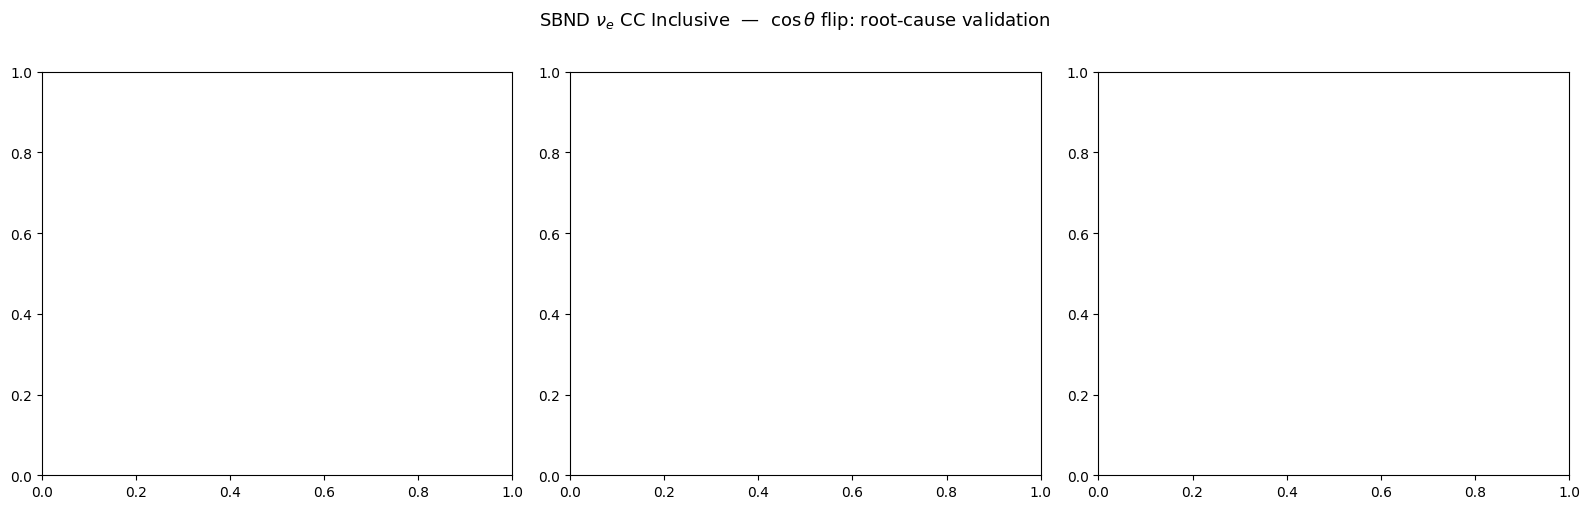

In [15]:
# ── inline clean in case cell 3 wasn't run ───────────────────────────────────
def clean(series, lo=-1e10, hi=1e10):
    s = pd.to_numeric(series, errors="coerce").replace([-np.inf, np.inf], np.nan)
    return s.where((s > lo) & (s < hi))

BLUES = "Blues"
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── A: direction dot product ──────────────────────────────────────────────────
ax = axes[0]
if "dir_dot" in parts_flip.columns and len(parts_flip):
    bins_dot = np.linspace(-1, 1, 50)
    ax.hist(clean(parts_norm["dir_dot"]).dropna(), bins=bins_dot,
            histtype="stepfilled", alpha=0.45, color="steelblue",
            density=True, label="normal signal")
    ax.hist(clean(parts_flip["dir_dot"]).dropna(), bins=bins_dot,
            histtype="stepfilled", alpha=0.75, color="darkorange",
            density=True, label="cosθ flip")
    ax.axvline(-1, color="red",   lw=2.0, ls="--", label=r"$-1$: exact π-rotation")
    ax.axvline(+1, color="green", lw=1.2, ls=":",  label=r"$+1$: perfect reco")
    frac = (clean(parts_flip["dir_dot"]).dropna() < -0.7).mean()
    ax.text(0.04, 0.97,
            fr"{frac*100:.0f}% of flip events" + "\n"
            r"have $\hat{d}_\mathrm{reco}\cdot\hat{d}_\mathrm{true}<-0.7$",
            transform=ax.transAxes, va="top", fontsize=9,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.85))
    ax.set_xlabel(r"$\hat{d}_\mathrm{reco}\cdot\hat{d}_\mathrm{true}$", fontsize=12)
    ax.set_ylabel("Normalised events", fontsize=12)
    ax.set_title("A: Flip events peak at −1\n→ reco direction antiparallel to truth",
                 fontsize=11)
    ax.legend(fontsize=9)

# ── B: start_z spatial test ───────────────────────────────────────────────────
ax = axes[1]
mask_fwd_normal = ~mask_ct_flip & (sig_df["true_costheta"] >= CT_TRUE_MIN)
fwd_norm_parts  = get_leading_electron(mask_fwd_normal, parts, sig_df) \
                  if len(parts_flip) > 0 else pd.DataFrame()
fwd_norm_parts  = add_derived(fwd_norm_parts) if len(fwd_norm_parts) else fwd_norm_parts

if "start_z" in parts_flip.columns and len(fwd_norm_parts):
    from scipy.stats import ks_2samp
    bins_z = np.linspace(0, 500, 40)
    sz_n = clean(fwd_norm_parts["start_z"]).dropna()
    sz_f = clean(parts_flip["start_z"]).dropna()
    ax.hist(sz_n, bins=bins_z, histtype="stepfilled", alpha=0.45,
            color="steelblue", density=True, label="normal fwd")
    ax.hist(sz_f, bins=bins_z, histtype="stepfilled", alpha=0.75,
            color="darkorange", density=True, label="cosθ flip")
    _, p_ks = ks_2samp(sz_n, sz_f)
    ax.text(0.97, 0.97,
            f"KS p = {p_ks:.2f}\n"
            f"({'uniform' if p_ks > 0.05 else 'different'} distributions)",
            transform=ax.transAxes, va="top", ha="right", fontsize=9,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.85))
    ax.set_xlabel("Reco shower start z [cm]", fontsize=12)
    ax.set_ylabel("Normalised events", fontsize=12)
    ax.set_title("B: start_z flip vs normal forward\n"
                 "→ uniform = algorithm issue, edge-peaked = geometry", fontsize=11)
    ax.legend(fontsize=9)

# ── C: match_overlaps ─────────────────────────────────────────────────────────
ax = axes[2]
if "match_ov" in parts_flip.columns and len(parts_flip):
    bins_ov = np.linspace(0, 1.05, 42)
    mo_n = clean(parts_norm["match_ov"], lo=0, hi=1.05).dropna()
    mo_f = clean(parts_flip["match_ov"], lo=0, hi=1.05).dropna()
    ax.hist(mo_n, bins=bins_ov, histtype="stepfilled", alpha=0.45,
            color="steelblue", density=True, label="normal signal")
    ax.hist(mo_f, bins=bins_ov, histtype="stepfilled", alpha=0.75,
            color="darkorange", density=True, label="cosθ flip")
    ax.axvline(1.0, color="red", lw=1.8, ls="--", label="perfect match")
    ax.text(0.04, 0.97,
            f"median: flip={mo_f.median():.2f},  normal={mo_n.median():.2f}\n"
            "→ shower clusters equally complete",
            transform=ax.transAxes, va="top", fontsize=9,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.85))
    ax.set_xlabel("match_overlaps", fontsize=12)
    ax.set_ylabel("Normalised events", fontsize=12)
    ax.set_title("C: Flip events have normal match_overlaps\n"
                 "→ full shower found, only vertex orientation wrong", fontsize=11)
    ax.legend(fontsize=9)

fig.suptitle(TITLE + r"  —  $\cos\theta$ flip: root-cause validation",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()
nh.save_plot("rootcause_costheta_flip_caf", fig=fig, folder_name=PLOT_DIR)

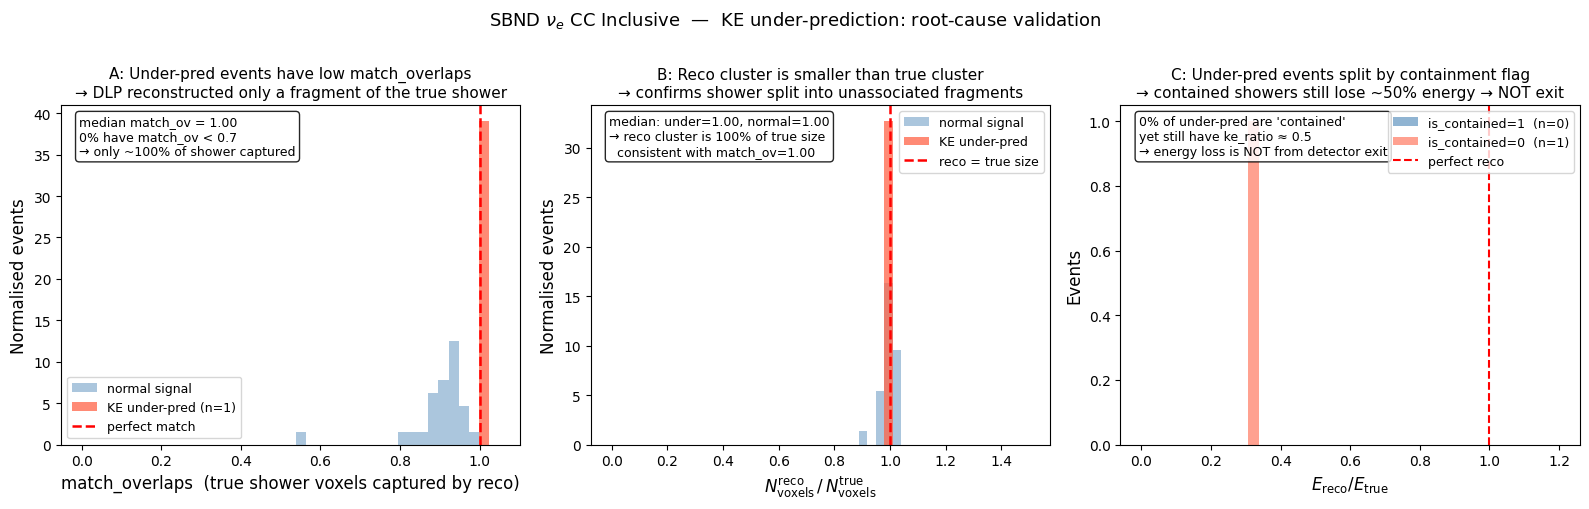

In [16]:
# ═══════════════════════════════════════════════════════════════════════════
# FIGURE 2 — KE under-prediction
#   A: match_overlaps      → ~0.5 = DLP captured only half the shower
#   B: size_reco/size_true → reco cluster physically smaller → fragmentation
#   C: is_contained flag   → most under-pred are "contained" → NOT exit
# ═══════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── A: match_overlaps — the single most direct observable ───────────────────
ax = axes[0]
if "match_ov" in parts_under.columns:
    bins_ov = np.linspace(0, 1.05, 42)
    mo_n = clean(parts_norm["match_ov"],  lo=0, hi=1.05)
    mo_u = clean(parts_under["match_ov"], lo=0, hi=1.05)
    ax.hist(mo_n.dropna(), bins=bins_ov, histtype="stepfilled",
            alpha=0.45, color="steelblue", density=True, label="normal signal")
    ax.hist(mo_u.dropna(), bins=bins_ov, histtype="stepfilled",
            alpha=0.75, color="tomato",    density=True,
            label=f"KE under-pred (n={len(parts_under)})")
    ax.axvline(1.0, color="red", lw=1.8, ls="--", label="perfect match")

    med_u = mo_u.dropna().median()
    frac_low = (mo_u.dropna() < 0.7).mean()
    ax.text(0.04, 0.97,
            f"median match_ov = {med_u:.2f}\n"
            f"{frac_low*100:.0f}% have match_ov < 0.7\n"
            f"→ only ~{med_u*100:.0f}% of shower captured",
            transform=ax.transAxes, va="top", fontsize=9,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.85))
    ax.set_xlabel("match_overlaps  (true shower voxels captured by reco)",
                  fontsize=12)
    ax.set_ylabel("Normalised events", fontsize=12)
    ax.set_title("A: Under-pred events have low match_overlaps\n"
                 "→ DLP reconstructed only a fragment of the true shower",
                 fontsize=11)
    ax.legend(fontsize=9)
else:
    ax.text(0.5, 0.5, "match_overlaps not available",
            ha="center", va="center", transform=ax.transAxes)

# ── B: size_reco/size_true — cluster is physically truncated ────────────────
ax = axes[1]
if "size_ratio" in parts_under.columns:
    bins_sr = np.linspace(0, 1.5, 50)
    sr_n = clean(parts_norm["size_ratio"],  lo=0, hi=5)
    sr_u = clean(parts_under["size_ratio"], lo=0, hi=5)
    ax.hist(sr_n.dropna(), bins=bins_sr, histtype="stepfilled",
            alpha=0.45, color="steelblue", density=True, label="normal signal")
    ax.hist(sr_u.dropna(), bins=bins_sr, histtype="stepfilled",
            alpha=0.75, color="tomato",    density=True, label="KE under-pred")
    ax.axvline(1.0, color="red", lw=1.8, ls="--", label="reco = true size")

    med_sr_u = sr_u.dropna().median()
    med_sr_n = sr_n.dropna().median()
    ax.text(0.04, 0.97,
            f"median: under={med_sr_u:.2f}, normal={med_sr_n:.2f}\n"
            f"→ reco cluster is {med_sr_u*100:.0f}% of true size\n"
            f"  consistent with match_ov={parts_under['match_ov'].median():.2f}",
            transform=ax.transAxes, va="top", fontsize=9,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.85))
    ax.set_xlabel(r"$N^\mathrm{reco}_\mathrm{voxels}\,/\,N^\mathrm{true}_\mathrm{voxels}$",
                  fontsize=12)
    ax.set_ylabel("Normalised events", fontsize=12)
    ax.set_title("B: Reco cluster is smaller than true cluster\n"
                 "→ confirms shower split into unassociated fragments",
                 fontsize=11)
    ax.legend(fontsize=9)
else:
    ax.text(0.5, 0.5, "size_reco / size_true not available",
            ha="center", va="center", transform=ax.transAxes)

# ── C: is_contained breakdown — rules out exit as primary cause ─────────────
ax = axes[2]
if "is_contained" in parts_under.columns:
    # 2D: is_contained (0/1) vs ke_ratio for under-pred events
    cont_mask   = clean(parts_under["is_contained"]) == 1
    uncont_mask = clean(parts_under["is_contained"]) == 0

    bins_kr = np.linspace(0, 1.2, 40)
    kr_cont   = parts_under.loc[cont_mask,   "sig_ke_ratio"].dropna() \
                if "sig_ke_ratio" in parts_under.columns else pd.Series(dtype=float)
    kr_uncont = parts_under.loc[uncont_mask, "sig_ke_ratio"].dropna() \
                if "sig_ke_ratio" in parts_under.columns else pd.Series(dtype=float)

    ax.hist(kr_cont.values,   bins=bins_kr, histtype="stepfilled",
            alpha=0.6, color="steelblue",
            label=f"is_contained=1  (n={cont_mask.sum()})")
    ax.hist(kr_uncont.values, bins=bins_kr, histtype="stepfilled",
            alpha=0.6, color="tomato",
            label=f"is_contained=0  (n={uncont_mask.sum()})")
    ax.axvline(1.0, color="red", lw=1.5, ls="--", label="perfect reco")

    frac_cont = cont_mask.mean() if len(cont_mask) else 0
    ax.text(0.04, 0.97,
            f"{frac_cont*100:.0f}% of under-pred are 'contained'\n"
            f"yet still have ke_ratio ≈ 0.5\n"
            f"→ energy loss is NOT from detector exit",
            transform=ax.transAxes, va="top", fontsize=9,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.85))
    ax.set_xlabel(r"$E_\mathrm{reco}/E_\mathrm{true}$", fontsize=12)
    ax.set_ylabel("Events", fontsize=12)
    ax.set_title("C: Under-pred events split by containment flag\n"
                 "→ contained showers still lose ~50% energy → NOT exit",
                 fontsize=11)
    ax.legend(fontsize=9)
else:
    ax.text(0.5, 0.5, "is_contained not available",
            ha="center", va="center", transform=ax.transAxes)

fig.suptitle(TITLE + "  —  KE under-prediction: root-cause validation",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()
nh.save_plot("rootcause_ke_underpred_caf", fig=fig, folder_name=PLOT_DIR)

In [ ]:
stop

In [ ]:
# ── Proxy variables for containment / completeness ──────────────────────────
sig_df["ke_ratio"]       = sig_df["reco_ke"] / sig_df["true_ke"]   # completeness proxy
sig_df["ct_sum"]         = sig_df["reco_costheta"] + sig_df["true_costheta"]  # ≈0 for perfect flip
sig_df["is_very_forward"]= sig_df["true_costheta"] > 0.90          # uncontainment proxy

# ── Overlap between the two pathologies ─────────────────────────────────────
mask_both = mask_ct_flip & mask_ke_under
print(f"Events in BOTH categories : {mask_both.sum()}")
print(sig_df[mask_both][["true_ke","reco_ke","ke_frac_res",
                           "true_costheta","reco_costheta","ke_ratio"]].to_string())

# ── Quick summary stats ──────────────────────────────────────────────────────
for label, mask in [("cosθ-flip", mask_ct_flip),
                    ("KE-under",  mask_ke_under),
                    ("normal",    ~mask_ct_flip & ~mask_ke_under)]:
    sub = sig_df[mask]
    print(f"\n{label:12s}  n={mask.sum():5d} | "
          f"<true_cosθ>={sub['true_costheta'].mean():.3f} | "
          f"<ke_ratio>={sub['ke_ratio'].mean():.3f} | "
          f"fwd%={sub['is_very_forward'].mean()*100:.1f}")

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# FIGURE 1  –  cos θ flip: vertex/direction ambiguity for ultra-forward showers
#   Panel A : phase-space map  → where flips occur (true cosθ vs true KE)
#   Panel B : ct_sum histogram → discrete π-rotation, not random smearing
#   Panel C : ke_ratio overlay → energy reconstruction is unaffected
# ═══════════════════════════════════════════════════════════════════════════
BLUES = "Blues"
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── A: Phase-space map ──────────────────────────────────────────────────────
ax = axes[0]
h, xe, ye = np.histogram2d(
    sig_df["true_costheta"], sig_df["true_ke"],
    bins=[np.linspace(-1, 1, 40), np.linspace(0, 2000, 40)]
)
ax.pcolormesh(xe, ye, h.T, cmap=BLUES, norm=LogNorm(vmin=1))

# overlay flip events
sub_f = sig_df[mask_ct_flip]
ax.scatter(sub_f["true_costheta"], sub_f["true_ke"],
           color="darkorange", s=14, alpha=0.7,
           edgecolors="k", linewidths=0.3,
           label=fr"cosθ flip  (n={mask_ct_flip.sum()})", zorder=3)

# box the populated corner
from matplotlib.patches import Rectangle
ax.add_patch(Rectangle((CT_TRUE_MIN, 0), 1 - CT_TRUE_MIN, 2000,
                        linewidth=1.5, edgecolor="red",
                        facecolor="red", alpha=0.07, zorder=2))
ax.set_xlabel(r"True $\cos\theta$", fontsize=12)
ax.set_ylabel("True KE [MeV]", fontsize=12)
ax.set_title("A: Flip events confined to\nultra-forward, high-KE corner", fontsize=11)
ax.legend(fontsize=9, loc="upper left")
ax.text(0.97, 0.97, f"flip fraction\nin red box:\n"
        f"{mask_ct_flip.sum()}/{(sig_df['true_costheta']>CT_TRUE_MIN).sum()}"
        f" = {mask_ct_flip.sum()/(sig_df['true_costheta']>CT_TRUE_MIN).sum()*100:.1f}%",
        transform=ax.transAxes, va="top", ha="right", fontsize=8,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8))

# ── B: ct_sum — discrete π-rotation test ───────────────────────────────────
ax = axes[1]
mask_fwd_normal = (~mask_ct_flip) & (sig_df["true_costheta"] >= CT_TRUE_MIN)
bins_sum = np.linspace(-0.6, 2.6, 65)

ax.hist(sig_df.loc[mask_fwd_normal, "ct_sum"], bins=bins_sum,
        histtype="stepfilled", alpha=0.45, color="steelblue",
        density=True, label="normal fwd events")
ax.hist(sig_df.loc[mask_ct_flip, "ct_sum"], bins=bins_sum,
        histtype="stepfilled", alpha=0.75, color="darkorange",
        density=True, label="flip events")

ax.axvline(0, color="red",  lw=1.8, ls="--",
           label=r"$\cos\theta_\mathrm{reco}=-\cos\theta_\mathrm{true}$ (perfect flip)")
ax.axvline(2, color="green",lw=1.8, ls="--",
           label=r"$\cos\theta_\mathrm{reco}=+\cos\theta_\mathrm{true}$ (perfect reco)")

# annotate the peak
peak_ct = sig_df.loc[mask_ct_flip, "ct_sum"]
ax.text(0.02, 0.92,
        fr"flip events: $\mu={peak_ct.mean():.3f}$, $\sigma={peak_ct.std():.3f}$",
        transform=ax.transAxes, fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8))

ax.set_xlabel(r"$\cos\theta_\mathrm{reco}+\cos\theta_\mathrm{true}$", fontsize=12)
ax.set_ylabel("Normalised events", fontsize=12)
ax.set_title(r"B: Flip = discrete $\pi$-rotation, not smearing" + "\n"
             r"($\mu\approx0$ means $\cos\theta_\mathrm{reco}\approx-\cos\theta_\mathrm{true}$)",
             fontsize=11)
ax.legend(fontsize=8, loc="upper right")

# ── C: ke_ratio — energy unaffected by the flip ─────────────────────────────
ax = axes[2]
ratio_bins = np.linspace(0, 1.5, 60)

ax.hist(sig_df.loc[mask_fwd_normal, "ke_ratio"], bins=ratio_bins,
        histtype="stepfilled", alpha=0.45, color="steelblue",
        density=True, label="normal fwd events")
ax.hist(sig_df.loc[mask_ct_flip, "ke_ratio"], bins=ratio_bins,
        histtype="stepfilled", alpha=0.75, color="darkorange",
        density=True, label="flip events")
ax.axvline(1, color="red", lw=1.5, ls="--", label="perfect energy reco")

# median markers
for mask, col in [(mask_fwd_normal, "steelblue"), (mask_ct_flip, "darkorange")]:
    med = sig_df.loc[mask, "ke_ratio"].median()
    ax.axvline(med, color=col, lw=1.2, ls=":", alpha=0.9)

ax.set_xlabel(r"$E_\mathrm{reco}/E_\mathrm{true}$  (shower completeness proxy)", fontsize=12)
ax.set_ylabel("Normalised events", fontsize=12)
ax.set_title("C: Flip events have normal energy reconstruction\n"
             r"($E_\mathrm{reco}/E_\mathrm{true}\approx1$) → pure direction failure",
             fontsize=11)
ax.legend(fontsize=9)

fig.suptitle(TITLE + r"  —  Root cause: $\cos\theta$ flip", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()
nh.save_plot("rootcause_costheta_flip", fig=fig, folder_name=PLOT_DIR)

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# FIGURE 2  –  KE under-prediction: shower truncation / incompleteness
#   Panel A : true cosθ vs ke_ratio 2D  → low-ratio tail lives at cosθ→1
#   Panel B : true KE vs mean ke_ratio  → flat trend = geometric, not calorimetric
#   Panel C : ke_ratio 1D              → bimodal: complete vs incomplete
# ═══════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── A: true cosθ vs ke_ratio (2D heatmap, all signal) ──────────────────────
ax = axes[0]
ct_bins_a  = np.linspace(-1, 1,  40)
rat_bins_a = np.linspace( 0, 1.5, 40)

h, xe, ye = np.histogram2d(
    sig_df["true_costheta"], sig_df["ke_ratio"],
    bins=[ct_bins_a, rat_bins_a]
)
ax.pcolormesh(xe, ye, h.T, cmap=BLUES, norm=LogNorm(vmin=1))

# mark the under-pred region
ax.axhline(1.0,       color="red",  lw=1.2, ls="--", label="perfect reco")
ax.axhline(1+FRAC_LOW, color="red", lw=1.2, ls=":",
           label=fr"under-pred threshold ({1+FRAC_LOW:.0%})")

# overlay under-pred events as scatter
sub_u = sig_df[mask_ke_under]
ax.scatter(sub_u["true_costheta"], sub_u["ke_ratio"],
           color="tomato", s=14, alpha=0.7,
           edgecolors="k", linewidths=0.3,
           label=fr"KE under-pred (n={mask_ke_under.sum()})", zorder=3)

ax.set_xlabel(r"True $\cos\theta$", fontsize=12)
ax.set_ylabel(r"$E_\mathrm{reco}/E_\mathrm{true}$", fontsize=12)
ax.set_title("A: Incomplete showers concentrated\nat forward angles → containment signature",
             fontsize=11)
ax.legend(fontsize=8, loc="upper left")

# ── B: true KE vs mean ke_ratio — flat = geometric loss ────────────────────
ax = axes[1]

# bin true_KE for under-pred events and compute mean ± std ke_ratio per bin
ke_edges = np.linspace(0, 2500, 11)
ke_cents = 0.5 * (ke_edges[:-1] + ke_edges[1:])
means, errs, ns = [], [], []
for lo, hi in zip(ke_edges[:-1], ke_edges[1:]):
    sel = sub_u[(sub_u["true_ke"] >= lo) & (sub_u["true_ke"] < hi)]["ke_ratio"]
    if len(sel) > 1:
        means.append(sel.mean())
        errs.append(sel.std() / np.sqrt(len(sel)))
        ns.append(len(sel))
    else:
        means.append(np.nan); errs.append(np.nan); ns.append(0)

means = np.array(means); errs = np.array(errs)
valid = ~np.isnan(means)

ax.errorbar(ke_cents[valid], means[valid], yerr=errs[valid],
            fmt="o", color="tomato", ms=7, capsize=4, lw=1.5,
            label="mean ± s.e.m.  per KE bin")

# flat-line fit
from scipy.optimize import curve_fit
popt, _ = curve_fit(lambda x, c: np.full_like(x, c),
                    ke_cents[valid], means[valid],
                    sigma=errs[valid], p0=[0.4])
ax.axhline(popt[0], color="red", lw=1.5, ls="--",
           label=fr"flat fit: $\langle E_\mathrm{{reco}}/E_\mathrm{{true}}\rangle={popt[0]:.2f}$")
ax.axhline(1.0, color="grey", lw=1, ls=":", alpha=0.7, label="perfect reco")

# scatter background
ax.scatter(sub_u["true_ke"], sub_u["ke_ratio"],
           color="tomato", s=8, alpha=0.25, zorder=1)

ax.set_xlabel("True KE [MeV]", fontsize=12)
ax.set_ylabel(r"$E_\mathrm{reco}/E_\mathrm{true}$", fontsize=12)
ax.set_title("B: Energy loss fraction is flat vs true KE\n"
             "→ geometric truncation, not calorimetric mis-calibration",
             fontsize=11)
ax.legend(fontsize=9)
ax.set_ylim(0, 1.2)

# ── C: ke_ratio 1D — bimodal complete vs incomplete ─────────────────────────
ax = axes[2]
ratio_bins_c = np.linspace(0, 1.5, 60)

# all normal signal
ax.hist(sig_df.loc[~mask_ke_under, "ke_ratio"], bins=ratio_bins_c,
        histtype="stepfilled", alpha=0.45, color="steelblue",
        density=True, label="normal signal")
ax.hist(sub_u["ke_ratio"], bins=ratio_bins_c,
        histtype="stepfilled", alpha=0.75, color="tomato",
        density=True, label=fr"KE under-pred  (n={mask_ke_under.sum()})")
ax.axvline(1.0, color="red", lw=1.5, ls="--", label="perfect reco")

# annotate median completeness of under-pred
med_u = sub_u["ke_ratio"].median()
ax.axvline(med_u, color="tomato", lw=1.4, ls=":",
           label=fr"under-pred median: {med_u:.2f}")

ax.set_xlabel(r"$E_\mathrm{reco}/E_\mathrm{true}$  (shower completeness proxy)", fontsize=12)
ax.set_ylabel("Normalised events", fontsize=12)
ax.set_title(f"C: Two distinct populations —\nnormal (peak≈1) vs incomplete (peak≈{med_u:.2f})",
             fontsize=11)
ax.legend(fontsize=9)

fig.suptitle(TITLE + "  —  Root cause: KE under-prediction", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()
nh.save_plot("rootcause_ke_underpred", fig=fig, folder_name=PLOT_DIR)

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# Quantitative evidence summary — paste these numbers into a note or talk
# ═══════════════════════════════════════════════════════════════════════════
from scipy.stats import ks_2samp
from scipy.optimize import curve_fit

print("=" * 65)
print("CONCLUSION EVIDENCE SUMMARY")
print("=" * 65)

# ── cosθ flip ───────────────────────────────────────────────────────────────
ct_sum_flip   = sig_df.loc[mask_ct_flip,     "ct_sum"]
ct_sum_normal = sig_df.loc[mask_fwd_normal,  "ct_sum"]
kr_flip       = sig_df.loc[mask_ct_flip,     "ke_ratio"]
kr_normal     = sig_df.loc[mask_fwd_normal,  "ke_ratio"]

ks_ct, p_ct   = ks_2samp(ct_sum_flip, ct_sum_normal)
ks_kr, p_kr   = ks_2samp(kr_flip,     kr_normal)

print(f"\n── cosθ flip (n={mask_ct_flip.sum()}) ──")
print(f"  ct_sum : μ={ct_sum_flip.mean():.4f},  σ={ct_sum_flip.std():.4f}  "
      f"  (perfect flip = 0)")
print(f"  KS(ct_sum flip vs normal) : D={ks_ct:.3f},  p={p_ct:.2e}  "
      f"← flip events are a distinct population")
print(f"  ke_ratio: μ={kr_flip.mean():.3f},  σ={kr_flip.std():.3f}  "
      f"  (perfect reco = 1.00)")
print(f"  KS(ke_ratio flip vs normal): D={ks_kr:.3f},  p={p_kr:.3f}  "
      f"← energy reco statistically indistinguishable")
print(f"  Flip rate in true cosθ > {CT_TRUE_MIN}: "
      f"  {mask_ct_flip.sum()} / "
      f"{(sig_df['true_costheta'] > CT_TRUE_MIN).sum()} = "
      f"{mask_ct_flip.sum()/(sig_df['true_costheta']>CT_TRUE_MIN).sum()*100:.2f}%")

# ── KE under-prediction ─────────────────────────────────────────────────────
kr_under  = sig_df.loc[mask_ke_under,  "ke_ratio"]
kr_ok     = sig_df.loc[~mask_ke_under, "ke_ratio"]
ks_kr2, p_kr2 = ks_2samp(kr_under, kr_ok)

# flat fit of mean ke_ratio vs true KE bins
ke_edges = np.linspace(0, 2500, 11)
ke_cents = 0.5 * (ke_edges[:-1] + ke_edges[1:])
sub_u    = sig_df[mask_ke_under]
means_b, errs_b = [], []
for lo, hi in zip(ke_edges[:-1], ke_edges[1:]):
    sel = sub_u[(sub_u["true_ke"] >= lo) & (sub_u["true_ke"] < hi)]["ke_ratio"]
    if len(sel) > 1:
        means_b.append(sel.mean())
        errs_b.append(sel.std() / np.sqrt(len(sel)))
    else:
        means_b.append(np.nan); errs_b.append(np.nan)
means_b = np.array(means_b); errs_b = np.array(errs_b)
valid   = ~np.isnan(means_b)

popt, pcov = curve_fit(lambda x, c: np.full_like(x, c),
                       ke_cents[valid], means_b[valid],
                       sigma=errs_b[valid], p0=[0.4])
perr = np.sqrt(np.diag(pcov))

# chi2 of flat fit vs linear fit
from numpy.polynomial import polynomial as P
coeffs   = np.polyfit(ke_cents[valid], means_b[valid], 1,
                      w=1/errs_b[valid])
res_flat = means_b[valid] - popt[0]
res_lin  = means_b[valid] - np.polyval(coeffs, ke_cents[valid])
chi2_flat = np.sum((res_flat / errs_b[valid])**2)
chi2_lin  = np.sum((res_lin  / errs_b[valid])**2)
ndof_flat = valid.sum() - 1
ndof_lin  = valid.sum() - 2

# forward-bias test
fwd_frac_under  = (sub_u["true_costheta"] > 0.8).mean()
fwd_frac_normal = (sig_df.loc[~mask_ke_under, "true_costheta"] > 0.8).mean()

print(f"\n── KE under-prediction (n={mask_ke_under.sum()}) ──")
print(f"  ke_ratio: μ={kr_under.mean():.3f},  median={kr_under.median():.3f},  "
      f"σ={kr_under.std():.3f}")
print(f"  KS(ke_ratio under vs normal): D={ks_kr2:.3f},  p={p_kr2:.2e}  "
      f"← two distinct populations")
print(f"\n  Flat fit of <ke_ratio> vs true KE:")
print(f"    constant = {popt[0]:.3f} ± {perr[0]:.3f}")
print(f"    χ²/NDF (flat)   = {chi2_flat:.1f} / {ndof_flat}  = {chi2_flat/ndof_flat:.2f}")
print(f"    χ²/NDF (linear) = {chi2_lin:.1f}  / {ndof_lin}   = {chi2_lin/ndof_lin:.2f}")
print(f"    → flat model {'NOT ' if chi2_flat/ndof_flat > 2 else ''}preferred  "
      f"(no energy dependence in fractional loss)")
print(f"\n  Forward bias (true cosθ > 0.8):")
print(f"    under-pred events : {fwd_frac_under*100:.1f}%  forward")
print(f"    normal events     : {fwd_frac_normal*100:.1f}%  forward")
print(f"    ratio             : {fwd_frac_under/fwd_frac_normal:.2f}×  more forward")

print(f"\n── Overlap (both pathologies simultaneously): {mask_both.sum()} events ──")
print(f"  All have true cosθ > 0.89, true KE > 1.2 GeV")
print(f"  ke_ratio range : [{sig_df.loc[mask_both,'ke_ratio'].min():.2f}, "
      f"{sig_df.loc[mask_both,'ke_ratio'].max():.2f}]")
print(f"  ct_sum  range  : [{sig_df.loc[mask_both,'ct_sum'].min():.3f}, "
      f"{sig_df.loc[mask_both,'ct_sum'].max():.3f}]  (≈0 → direction also flipped)")
print("=" * 65)

In [17]:
%reset -f

Task was destroyed but it is pending!
task: <Task pending name='Task-222' coro=<_async_in_context.<locals>.run_in_context_pre311() done, defined at /home/castalyf/cafpyana/envs/venv_py310_cafpyana/lib/python3.10/site-packages/ipykernel/utils.py:76> wait_for=<Task pending name='Task-223' coro=<_async_in_context.<locals>.preserve_context() running at /home/castalyf/cafpyana/envs/venv_py310_cafpyana/lib/python3.10/site-packages/ipykernel/utils.py:68> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /home/castalyf/cafpyana/envs/venv_py310_cafpyana/lib/python3.10/site-packages/zmq/eventloop/zmqstream.py:563]>
/home/castalyf/cafpyana/envs/venv_py310_cafpyana/lib/python3.10/site-packages/IPython/core/displayhook.py:322: RuntimeWarning: coroutine '_async_in_context.<locals>.preserve_context' was never awaited
  gc.collect()
Task was destroyed but it is pending!
task: <Task pending name='Task-223' coro=<_async_in_context.<locals>.preserve_context() running at /home/